In [1]:
#%pip install rasterstats
#%pip install git+https://github.com/Nadiesenali/snowdroughtindex-main
import geopandas as gpd
import rasterio
from rasterio.merge import merge
from rasterstats import zonal_stats
from rasterio.mask import mask
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.patches as mpatches

In [14]:
shapefile_path = r"C:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\snowdroughtindex-main\data\input_data\shapefiles\BowRiverBasin\Bow.shp"
output_data = r"C:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\snowdroughtindex-main\data\output_data\elevation\\"
output_plots = r"C:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\snowdroughtindex-main\data\output_plots\for_paper\elevation\\"
tif_files = glob.glob(r"C:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\Reasearch\Data\research_area\Elevation\New folder\*.tif")


In [5]:
# 1. Load Shapefile ===
gdf = gpd.read_file(shapefile_path)

In [6]:
# 2. Merge the TIFs ===
src_files_to_mosaic = [rasterio.open(fp) for fp in tif_files]
mosaic, out_transform = merge(src_files_to_mosaic)

In [7]:
# 3. Write the Merged Raster to Disk ===
mosaic_meta = src_files_to_mosaic[0].meta.copy()
mosaic_meta.update({
    "driver": "GTiff",
    "height": mosaic.shape[1],
    "width": mosaic.shape[2],
    "transform": out_transform
})

merged_tif_path = output_data+"merged_dem.tif"
with rasterio.open(merged_tif_path, "w", **mosaic_meta) as dest:
    dest.write(mosaic)

In [9]:
# 4. Compute Zonal Statistics ===
stats = zonal_stats(
    shapefile_path,
    merged_tif_path,
    stats=["min", "max", "mean", "std", "median", "count"],
    nodata=None,
    geojson_out=True
)

In [10]:
# 5. Create GeoDataFrame with Stats ===
stats_gdf = gpd.GeoDataFrame.from_features(stats)

In [3]:
# 6. Save to New Shapefile or CSV ===
output_shapefile_path = os.path.join(output_data, "Bow_elevation_with_stats.shp")
output_dir = os.path.dirname(output_shapefile_path)
output_csv_path = os.path.join(output_dir, "Bow_stats.csv")

# save the GeoDataFrame to a shapefile
#stats_gdf.to_file(output_shapefile_path)  # Save as shapefile
#stats_gdf.drop(columns="geometry").to_csv(output_csv_path, index=False)  # Also save as CSV

print("✅ Elevation statistics extracted and saved.")

NameError: name 'output_data' is not defined

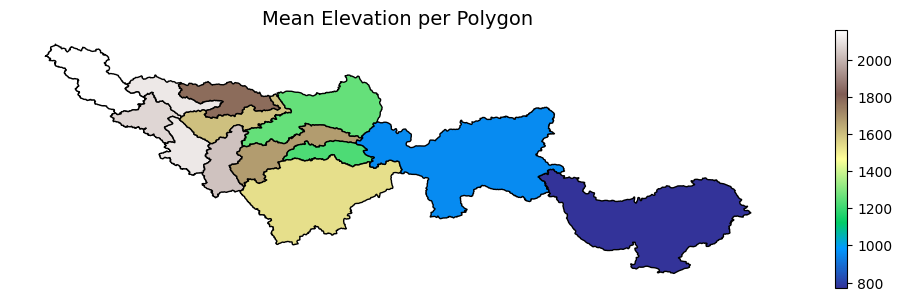

In [12]:
# Load shapefile with elevation stats
gdf = stats_gdf.copy()

# Plot mean elevation
fig, ax = plt.subplots(figsize=(10, 3))
gdf.plot(column='mean', cmap='terrain', legend=True, edgecolor='black', ax=ax)

ax.set_title("Mean Elevation per Polygon", fontsize=14)
ax.axis('off')
plt.tight_layout()
# Save the plot
plt.savefig(os.path.join(output_plots, "mean_elevation_plot.png"), dpi=300)
plt.show()

In [13]:
# Clip the merged DEM using the geometry from the shapefile
with rasterio.open(merged_tif_path) as src:
	# Use all geometries from the GeoDataFrame
	shapes = [feature["geometry"] for feature in stats]
	clipped_dem, clipped_transform = mask(src, shapes=shapes, crop=True)

C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_28424\2483319816.py:50: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticks(), fontsize=15, family="Times New Roman")
C:\Users\walimunige.rupasingh\AppData\Local\Temp\ipykernel_28424\2483319816.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticks(), fontsize=15, family="Times New Roman")


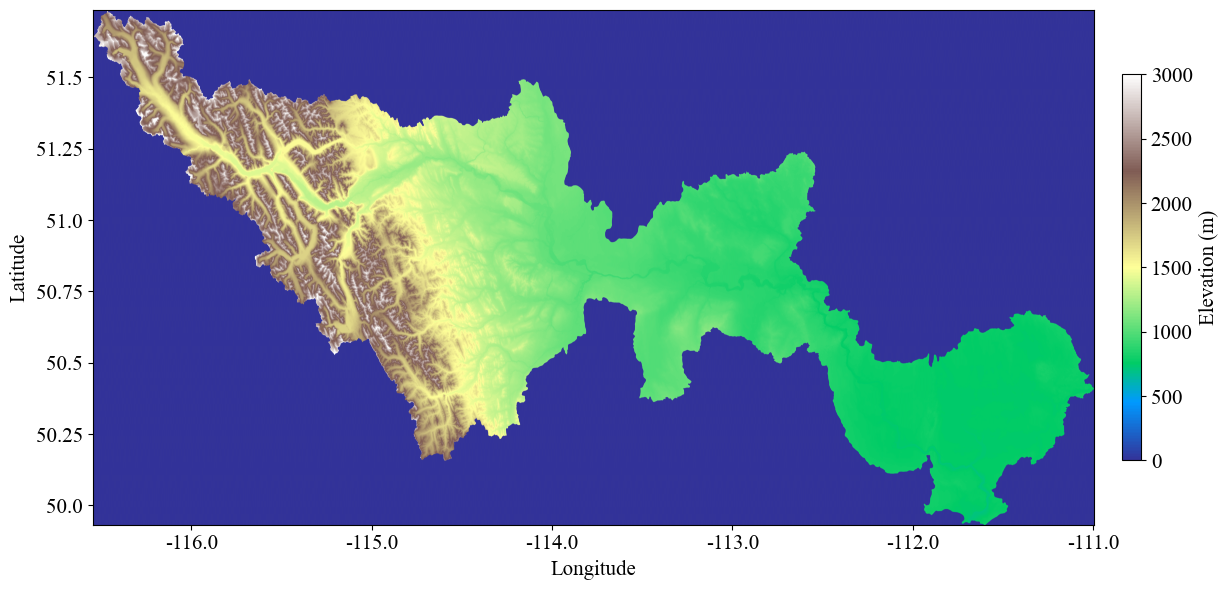

In [19]:
# Mask nodata using mosaic_meta or assume 0 is nodata if not set
nodata_value = mosaic_meta.get("nodata", 0)
clipped_data = np.where(clipped_dem[0] == nodata_value, np.nan, clipped_dem[0])

extent = [
    clipped_transform.c,
    clipped_transform.c + clipped_data.shape[1] * clipped_transform.a,
    clipped_transform.f + clipped_data.shape[0] * clipped_transform.e,
    clipped_transform.f
]

mean_lat = (extent[2] + extent[3]) / 2
aspect = 1 / np.cos(np.deg2rad(mean_lat))



fig, ax = plt.subplots(figsize=(15, 6))

im = ax.imshow(
    clipped_data,
    cmap="terrain",
    vmin=0,
    vmax=3000,
    extent=extent
)

ax.set_aspect(aspect)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="vertical",
    pad=0.02,
    fraction=0.03,
    shrink=0.75
)

# set colorbar tick label size and font family correctly
plt.setp(cbar.ax.get_yticklabels(), fontsize=15, family="Times New Roman")
cbar.set_label("Elevation (m)", fontsize=15, family="Times New Roman")

# axis labels and tick label fonts
ax.set_xlabel("Longitude", fontsize=15, family="Times New Roman")
ax.set_ylabel("Latitude", fontsize=15, family="Times New Roman")
plt.setp(ax.get_xticklabels(), fontsize=15, family="Times New Roman")
plt.setp(ax.get_yticklabels(), fontsize=15, family="Times New Roman")


ax.set_xlabel("Longitude", fontsize=15, family="Times New Roman")
ax.set_yticklabels(ax.get_yticks(), fontsize=15, family="Times New Roman")
ax.set_xticklabels(ax.get_xticks(), fontsize=15, family="Times New Roman")
ax.set_ylabel("Latitude", fontsize=15, family="Times New Roman")

plt.tight_layout()
# Save the current figure as a PNG file in the output_path directory
plt.savefig(os.path.join(output_plots, 'clipped_elevation_map.png'), dpi=1000, bbox_inches='tight')
plt.show()

In [67]:
# Split polygons into elevation classes and save separate shapefiles

# Define elevation bins (adjust as needed)
elevation_bins = [0, 500, 1000, 1500, 2000,2500, 3000]
elevation_labels = [f"{elevation_bins[i]}_{elevation_bins[i+1]}m" for i in range(len(elevation_bins)-1)]

# Ensure 'mean' column exists in stats_gdf
if 'mean' in stats_gdf.columns:
    stats_gdf['elev_class'] = pd.cut(stats_gdf['mean'], bins=elevation_bins, labels=elevation_labels, include_lowest=True)
    # Convert to string for shapefile output
    stats_gdf['elev_class'] = stats_gdf['elev_class'].astype(str)
    for label in elevation_labels:
        subset = stats_gdf[stats_gdf['elev_class'] == str(label)]
        if not subset.empty:
            out_path = os.path.join(output_dir, f"Bow_elevation_{label}.shp")
            subset.to_file(out_path)
            print(f"Saved: {out_path}")
else:
    print("Column 'mean' not found in stats_gdf.")

Saved: C:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\snowdroughtindex-main\data\output_data\elevation\Bow_elevation_500_1000m.shp
Saved: C:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\snowdroughtindex-main\data\output_data\elevation\Bow_elevation_1000_1500m.shp
Saved: C:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\snowdroughtindex-main\data\output_data\elevation\Bow_elevation_1500_2000m.shp
Saved: C:\Users\walimunige.rupasingh\OneDrive - University of Calgary\Documents\GitHub\snowdroughtindex-main\data\output_data\elevation\Bow_elevation_2000_2500m.shp


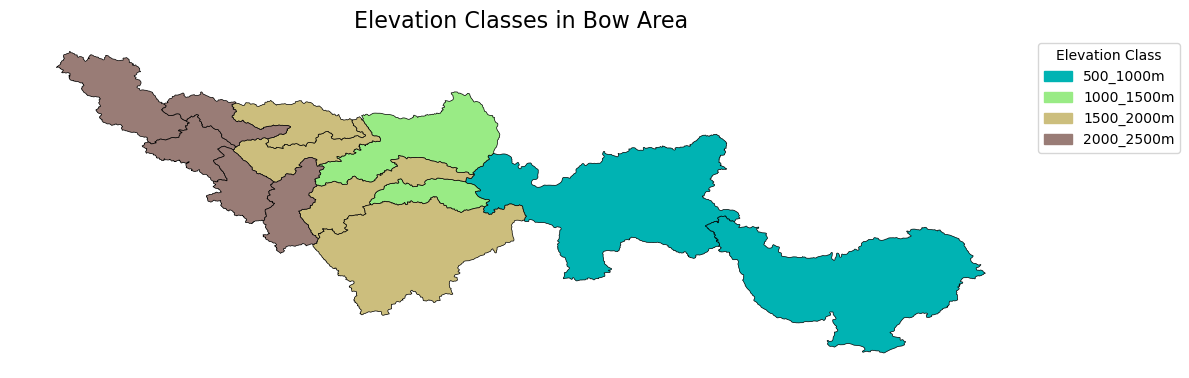

In [69]:
# Plot all elevation class shapefiles in one plot

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.terrain(np.linspace(0, 1, len(elevation_labels)))
legend_handles = []

for i, label in enumerate(elevation_labels):
    shp_path = os.path.join(output_dir, f"Bow_elevation_{label}.shp")
    if os.path.exists(shp_path):
        class_gdf = gpd.read_file(shp_path)
        class_gdf.plot(ax=ax, color=colors[i], label=label, edgecolor='black', linewidth=0.5)
        legend_handles.append(mpatches.Patch(color=colors[i], label=label))

ax.set_title("Elevation Classes in Bow Area", fontsize=16)
ax.axis('off')
ax.legend(handles=legend_handles,title="Elevation Class", loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(os.path.join(output_plots, 'Elevation_map.png'), dpi=300, bbox_inches='tight')
plt.show()



In [72]:
# join all elevation class shapefiles into one shapefile
all_classes = []
for label in elevation_labels:
    shp_path = os.path.join(output_data, f"Bow_elevation_{label}.shp")
    if os.path.exists(shp_path):
        class_gdf = gpd.read_file(shp_path)
        all_classes.append(class_gdf)
        if all_classes:
            combined_gdf = gpd.GeoDataFrame(pd.concat(all_classes, ignore_index=True))
            combined_gdf.to_file(os.path.join(output_data, "Bow_elevation_combined.shp"))
            print("Combined shapefile saved as Bow_elevation_combined.shp")

Combined shapefile saved as Bow_elevation_combined.shp
Combined shapefile saved as Bow_elevation_combined.shp
Combined shapefile saved as Bow_elevation_combined.shp
Combined shapefile saved as Bow_elevation_combined.shp
